In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

print('All libraries loaded')

Importing plotly failed. Interactive plots will not work.


All libraries loaded


In [2]:
DB_PATH = 'C:/Users/Saurabh yadav/Documents/SaaS Growth Intelligence Platform/database/saas_data.db'
conn = sqlite3.connect(DB_PATH)

subscriptions = pd.read_sql('SELECT * FROM subscriptions', conn)
conn.close()

subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])

print('Data loaded')
print('Shape:', subscriptions.shape)

Data loaded
Shape: (5000, 16)


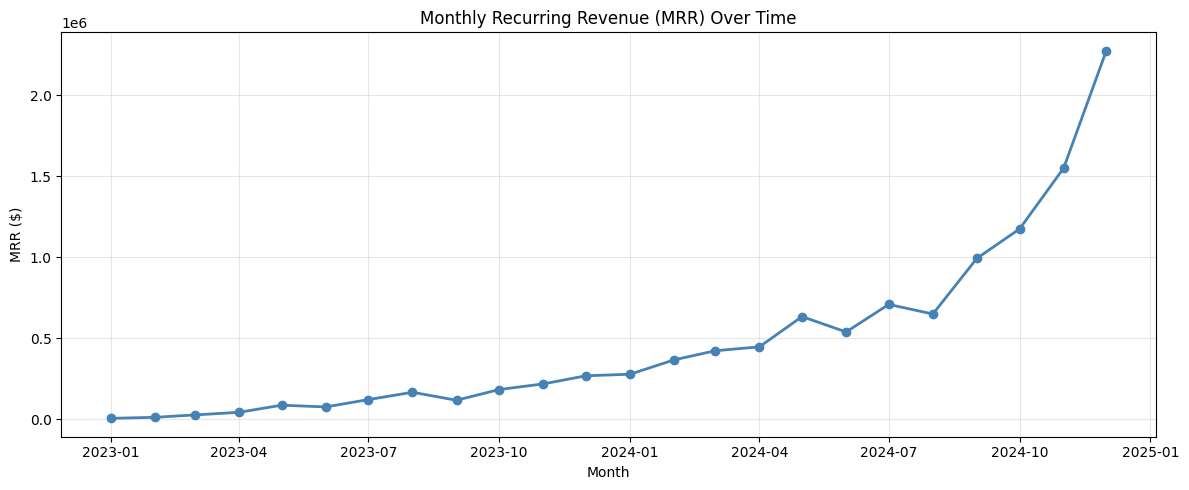

Total months of data: 24
Average monthly MRR: $ 472447.79
Latest MRR: $ 2273427


In [3]:
subscriptions['month'] = subscriptions['start_date'].dt.to_period('M')

monthly_mrr = subscriptions.groupby('month')['mrr_amount'].sum().reset_index()
monthly_mrr.columns = ['month', 'mrr']
monthly_mrr['month'] = monthly_mrr['month'].dt.to_timestamp()
monthly_mrr = monthly_mrr.sort_values('month').reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(monthly_mrr['month'], monthly_mrr['mrr'], marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Recurring Revenue (MRR) Over Time')
plt.xlabel('Month')
plt.ylabel('MRR ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Total months of data:', len(monthly_mrr))
print('Average monthly MRR: $', round(monthly_mrr['mrr'].mean(), 2))
print('Latest MRR: $', round(monthly_mrr['mrr'].iloc[-1], 2))

In [4]:
prophet_df = monthly_mrr.rename(columns={'month': 'ds', 'mrr': 'y'})

split_index = int(len(prophet_df) * 0.8)
train_df = prophet_df.iloc[:split_index]
test_df  = prophet_df.iloc[split_index:]

model = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = False,
    daily_seasonality   = False,
    seasonality_mode    = 'multiplicative'
)

model.fit(train_df)
print('Prophet model trained')
print('Training months:', len(train_df))
print('Test months:    ', len(test_df))

16:13:57 - cmdstanpy - INFO - Chain [1] start processing
16:14:03 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained
Training months: 19
Test months:     5


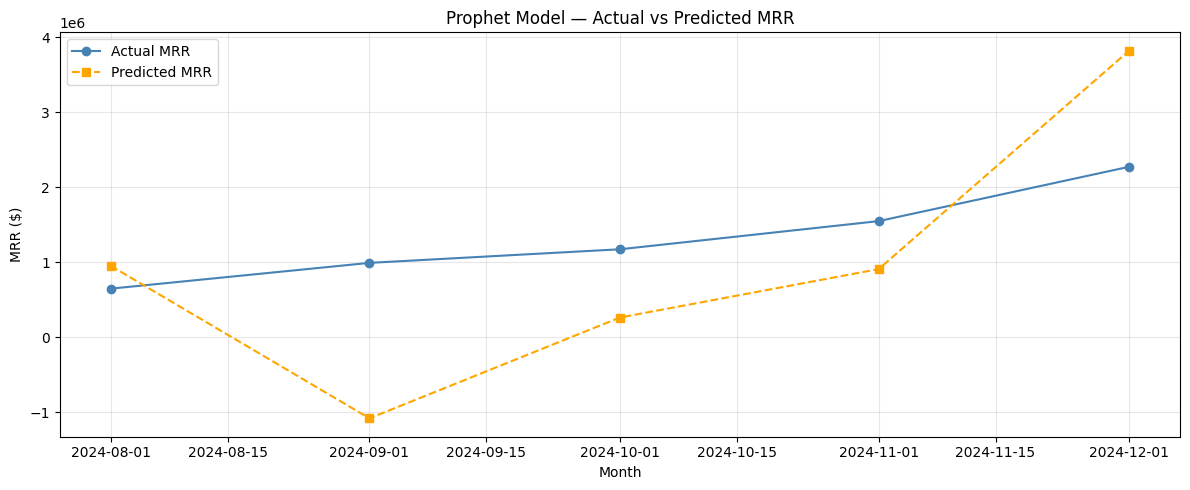

MAPE Score: 88.56 %
Lower MAPE = better accuracy


In [5]:
test_forecast = model.predict(test_df[['ds']])

actual    = test_df['y'].values
predicted = test_forecast['yhat'].values

mape = mean_absolute_percentage_error(actual, predicted) * 100

plt.figure(figsize=(12, 5))
plt.plot(test_df['ds'], actual,    marker='o', label='Actual MRR',    color='steelblue')
plt.plot(test_df['ds'], predicted, marker='s', label='Predicted MRR', color='orange', linestyle='--')
plt.title('Prophet Model — Actual vs Predicted MRR')
plt.xlabel('Month')
plt.ylabel('MRR ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('MAPE Score:', round(mape, 2), '%')
print('Lower MAPE = better accuracy')

16:14:15 - cmdstanpy - INFO - Chain [1] start processing
16:14:25 - cmdstanpy - INFO - Chain [1] done processing


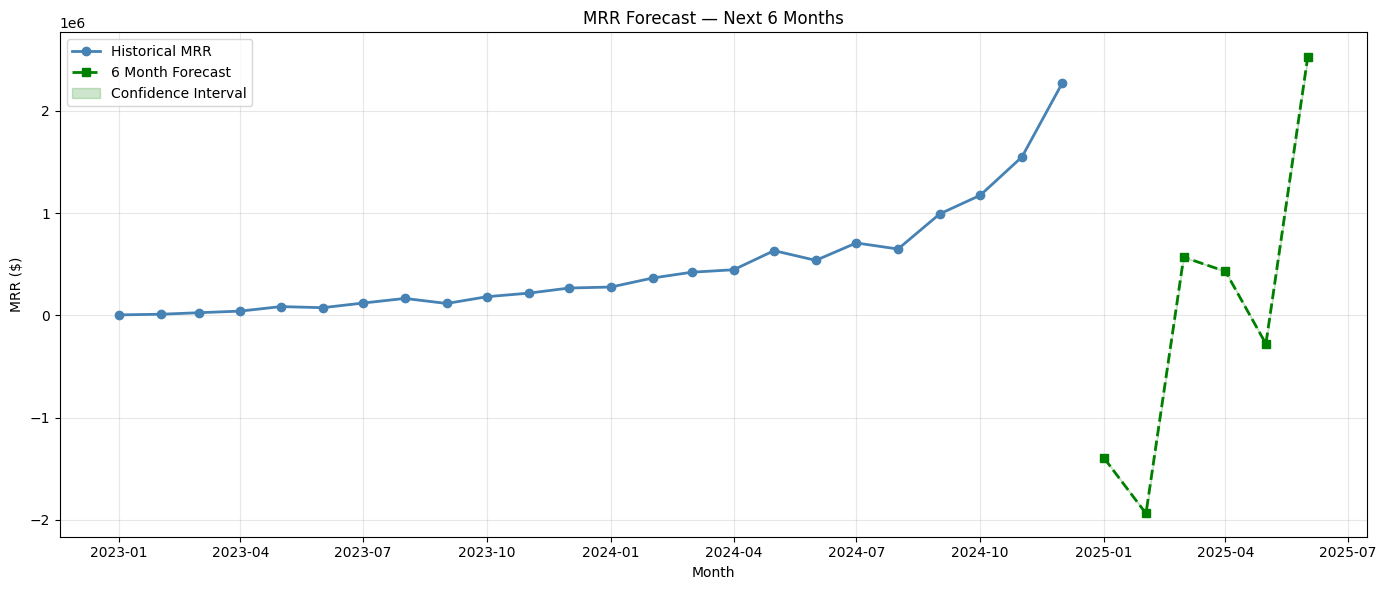

6 Month MRR Forecast:
     Month  Forecast MRR  Lower Bound  Upper Bound
2025-01-01   -1397136.69  -1397913.25  -1396404.83
2025-02-01   -1936278.80  -1939654.06  -1933129.36
2025-03-01     569040.29    567246.04    570878.80
2025-04-01     429558.44    427487.46    431566.62
2025-05-01    -278273.02   -280068.18   -276412.68
2025-06-01    2521784.58   2499753.46   2542541.18


C:\Users\Saurabh yadav\AppData\Local\Temp\ipykernel_2076\684357874.py:32: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  future_forecast = future_forecast.round(2)


In [6]:
full_model = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = False,
    daily_seasonality   = False,
    seasonality_mode    = 'multiplicative'
)
full_model.fit(prophet_df)

future     = full_model.make_future_dataframe(periods=6, freq='MS')
forecast   = full_model.predict(future)

plt.figure(figsize=(14, 6))
plt.plot(prophet_df['ds'], prophet_df['y'],
         marker='o', color='steelblue', label='Historical MRR', linewidth=2)
plt.plot(forecast['ds'].tail(6), forecast['yhat'].tail(6),
         marker='s', color='green', linestyle='--', label='6 Month Forecast', linewidth=2)
plt.fill_between(forecast['ds'].tail(6),
                 forecast['yhat_lower'].tail(6),
                 forecast['yhat_upper'].tail(6),
                 alpha=0.2, color='green', label='Confidence Interval')
plt.title('MRR Forecast — Next 6 Months')
plt.xlabel('Month')
plt.ylabel('MRR ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('6 Month MRR Forecast:')
future_forecast = forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(6)
future_forecast.columns = ['Month','Forecast MRR','Lower Bound','Upper Bound']
future_forecast = future_forecast.round(2)
print(future_forecast.to_string(index=False))

In [7]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///C:/Users/Saurabh yadav/Documents/SaaS Growth Intelligence Platform/database/saas_data.db')

forecast_to_save = forecast[['ds','yhat','yhat_lower','yhat_upper']].copy()
forecast_to_save.columns = ['month','forecast_mrr','lower_bound','upper_bound']
forecast_to_save['month'] = forecast_to_save['month'].astype(str)
forecast_to_save = forecast_to_save.round(2)

forecast_to_save.to_sql('mrr_forecast', engine, if_exists='replace', index=False)

print('Forecast saved to database')
print('Total rows saved:', len(forecast_to_save))
print('Phase 3 Complete! Ready for Power BI dashboard')

Forecast saved to database
Total rows saved: 30
Phase 3 Complete! Ready for Power BI dashboard
